<a href="https://colab.research.google.com/github/m1deey/Translater_version01/blob/main/Translater_version01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!wget http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip -O spa-eng.zip
!unzip spa-eng.zip

--2026-09-08 13:27:38--  http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.210.155, 142.251.215.219, 142.251.35.91, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.210.155|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2638744 (2.5M) [application/zip]
Saving to: ‘spa-eng.zip’

spa-eng.zip         100%[===================>]   2.52M  --.-KB/s    in 0.01s   

2026-09-08 13:27:38 (192 MB/s) - ‘spa-eng.zip’ saved [2638744/2638744]

Archive:  spa-eng.zip
   creating: spa-eng/
  inflating: spa-eng/_about.txt      
  inflating: spa-eng/spa.txt         


In [3]:
with open("spa-eng/spa.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()
print(lines[:5])

['Go.\tVe.\n', 'Go.\tVete.\n', 'Go.\tVaya.\n', 'Go.\tVáyase.\n', 'Hi.\tHola.\n']


In [4]:
import re

eng_texts, spa_texts = [], []
for line in lines:
    eng, spa = line.strip().split("\t")
    eng = re.sub(r"[^a-zA-Z?.!,¿]+", " ", eng).strip().lower()
    spa = re.sub(r"[^a-zA-ZñÑáéíóúÁÉÍÓÚ?.!,¿]+", " ", spa).strip().lower()
    spa = "<start> " + spa + " <end>"
    eng_texts.append(eng)
    spa_texts.append(spa)

print(eng_texts[:3])
print(spa_texts[:3])

['go.', 'go.', 'go.']
['<start> ve. <end>', '<start> vete. <end>', '<start> vaya. <end>']


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
eng_tok=Tokenizer(filters="")
eng_tok.fit_on_texts(eng_texts)
eng_seq=eng_tok.texts_to_sequences(eng_texts)
eng_pad=pad_sequences(eng_seq,padding="post")
spa_tok=Tokenizer(filters="")
spa_tok.fit_on_texts(spa_texts)
spa_seq=spa_tok.texts_to_sequences(spa_texts)
spa_pad=pad_sequences(spa_seq,padding="post")
print(eng_pad.shape,spa_pad.shape)
print(len(eng_tok.word_index),len(spa_tok.word_index))

(118964, 47) (118964, 51)
22417 40528


In [15]:
import numpy as np

MAX_LEN = 15
mask = (np.array([len(s) for s in eng_seq]) <= MAX_LEN) & (np.array([len(s) for s in spa_seq]) <= MAX_LEN)

eng_seqs_f = [s for s, m in zip(eng_seq, mask) if m]
spa_seqs_f = [s for s, m in zip(spa_seq, mask) if m]

eng_padded = pad_sequences(eng_seqs_f, maxlen=MAX_LEN, padding="post")
spa_padded = pad_sequences(spa_seqs_f, maxlen=MAX_LEN, padding="post")

print(eng_padded.shape, spa_padded.shape)

(116755, 15) (116755, 15)


In [19]:
from sklearn.model_selection import train_test_split
eng_train,eng_val,spa_train,spa_val=train_test_split(eng_padded,spa_padded,test_size=0.1,random_state=0)
print(eng_train.shape,eng_val.shape)

(105079, 15) (11676, 15)


In [23]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Attention, Concatenate
from tensorflow.keras.models import Model

EMBED_DIM = 128
UNITS = 256
ENG_VOCAB = len(eng_tok.word_index) + 1
SPA_VOCAB = len(spa_tok.word_index) + 1

# Encoder
encoder_inputs = Input(shape=(MAX_LEN,))
enc_emb = Embedding(ENG_VOCAB, EMBED_DIM, mask_zero=True)(encoder_inputs)
encoder_outputs, state_h, state_c = LSTM(UNITS, return_sequences=True, return_state=True, dropout=0.2, recurrent_dropout=0.2)(enc_emb)

# Decoder
decoder_inputs = Input(shape=(MAX_LEN,))
dec_emb = Embedding(SPA_VOCAB, EMBED_DIM, mask_zero=True)(decoder_inputs)
decoder_outputs, _, _ = LSTM(UNITS, return_sequences=True, return_state=True, dropout=0.2, recurrent_dropout=0.2)(dec_emb, initial_state=[state_h, state_c])

# Attention
attention = Attention()([decoder_outputs, encoder_outputs])
concat = Concatenate()([decoder_outputs, attention])

outputs = Dense(SPA_VOCAB, activation="softmax")(concat)

model = Model([encoder_inputs, decoder_inputs], outputs)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 15, 128)   │  2,869,504 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 15)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 15, 128)   │  5,187,712 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ [(None, 15, 256), │    394,240 │ embedding_2[0][0… │
│                     │ (None, 256),      │            │ not_equal_2[0][0] │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 15, 256), │    394,240 │ embedding_3[0][0… │
│                     │ (None, 256),      │            │ lstm_2[0][1],     │
│                     │ (None, 256)]      │            │ lstm_2[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 15, 256)   │          0 │ lstm_3[0][0],     │
│ (Attention)         │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 15, 512)   │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 15, 40529) │ 20,791,377 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,637,073 (113.06 MB)

 Trainable params: 29,637,073 (113.06 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

decoder_input_train = spa_train[:, :-1]
decoder_input_train = pad_sequences(decoder_input_train, maxlen=MAX_LEN, padding="post")
decoder_target_train = spa_train[:, 1:]
decoder_target_train = pad_sequences(decoder_target_train, maxlen=MAX_LEN, padding="post")

decoder_input_val = spa_val[:, :-1]
decoder_input_val = pad_sequences(decoder_input_val, maxlen=MAX_LEN, padding="post")
decoder_target_val = spa_val[:, 1:]
decoder_target_val = pad_sequences(decoder_target_val, maxlen=MAX_LEN, padding="post")

es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    [eng_train, decoder_input_train], decoder_target_train,
    validation_data=([eng_val, decoder_input_val], decoder_target_val),
    epochs=15,
    batch_size=64,
    callbacks=[es]
)

Epoch 1/15
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 754s 452ms/step - accuracy: 0.3593 - loss: 4.5890 - val_accuracy: 0.4684 - val_loss: 3.5258
Epoch 2/15
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 747s 455ms/step - accuracy: 0.5290 - loss: 2.9018 - val_accuracy: 0.5778 - val_loss: 2.6977
Epoch 3/15
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 751s 458ms/step - accuracy: 0.6169 - loss: 2.0785 - val_accuracy: 0.6245 - val_loss: 2.3666
Epoch 4/15
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 749s 456ms/step - accuracy: 0.6738 - loss: 1.5839 - val_accuracy: 0.6497 - val_loss: 2.2306
Epoch 5/15
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 751s 457ms/step - accuracy: 0.7197 - loss: 1.2580 - val_accuracy: 0.6634 - val_loss: 2.1736
Epoch 6/15
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 748s 455ms/step - accuracy: 0.7582 - loss: 1.0390 - val_accuracy: 0.6723 - val_loss: 2.1506
Epoch 7/15
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 749s 456ms/step - accuracy: 0.7863 - loss: 0.8901 - val_accuracy: 0.6777 - val_loss: 2.1462
Epoch 8/15
1642/1642 ━━━━━━━━━━━━━━━━━━━━ 747s 455ms/step - ac

In [35]:
def translate(sentence):
    sentence = re.sub(r"[^a-zA-Z?.!,¿]+", " ", sentence).strip().lower()
    seq = eng_tok.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post")

    target_seq = np.zeros((1, MAX_LEN))
    target_seq[0, 0] = spa_tok.word_index["<start>"]

    result = []
    for i in range(1, MAX_LEN):
        preds = model.predict([seq, target_seq], verbose=0)
        next_id = np.argmax(preds[0, i-1])
        word = spa_tok.index_word.get(next_id, "")
        if word == "<end>" or word == "":
            break
        result.append(word)
        target_seq[0, i] = next_id

    return " ".join(result)

print(translate("how are you?"))
print(translate("i love pizza"))
print(translate("what time is it?"))

¿cómo estás?
me encanta el rock.
¿qué hora es?


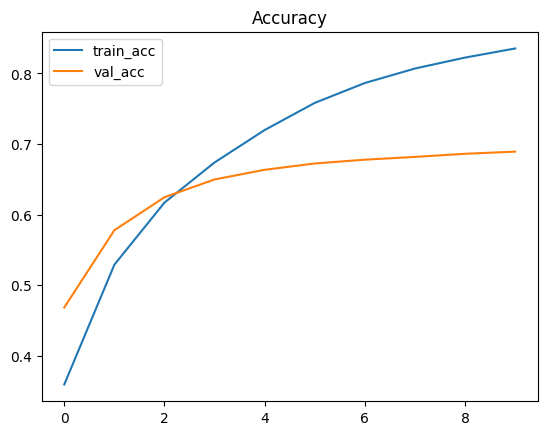

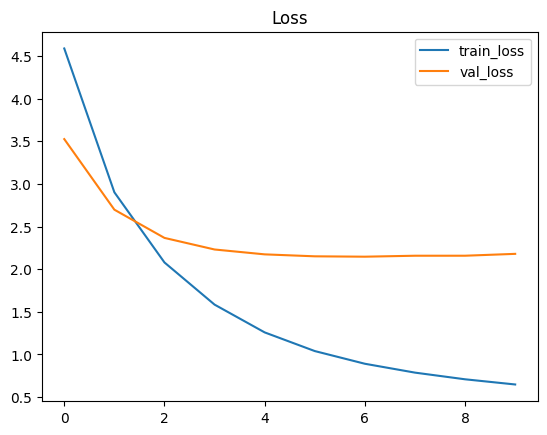

In [37]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()

In [40]:
model.save("translator_en_es.h5")

import pickle
with open("eng_tokenizer.pkl", "wb") as f:
    pickle.dump(eng_tok, f)
with open("spa_tokenizer.pkl", "wb") as f:
    pickle.dump(spa_tok, f)

In [41]:
from google.colab import files
files.download("translator_en_es.h5")
files.download("eng_tokenizer.pkl")
files.download("spa_tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
model.save("translator_en_es.keras")
files.download("translator_en_es.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>